In [1]:

import numpy as np
import matplotlib.pyplot as plt
from ModeloClassificado import fun_integrador, simular_2, fun_fsolve
from scipy.optimize import root
import casadi as ca
import pandas as pd

1670.8756184300632


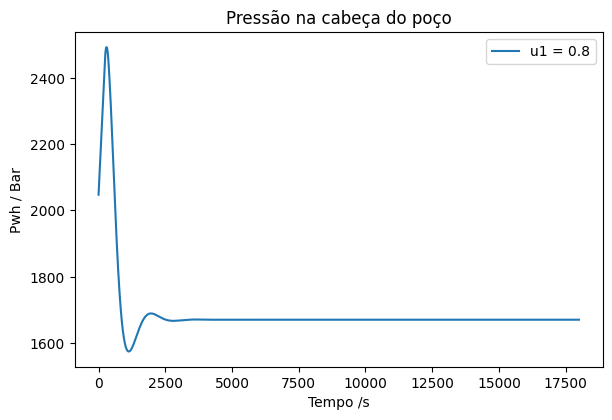

In [26]:


integrador, modelo = fun_integrador(dt=1)


y0 = [2045.7063 , 169.075,  9588.1742]
z0_vals = [
    7183839.554, 2991744.663, 7138588.549, 12043588.55,
    1.90714269, 14.13695208, 33.43556308, 2.911066071,
    30.52449701, 0.141369521, 281.8106616, 80.37817471
]

# Parâmetros ajustáveis
w_inj = 1.7
u1 = 0.8
GOR = 0.01
params = [w_inj, u1, GOR]

# Simulação
t0, tf, dt = 0, 18000, 1
t = np.arange(t0, tf, dt)

x_current = np.array(y0)
z_current = np.array(z0_vals)

results = simular_2(integrador, modelo, params, y0, z0_vals, t)


plt.figure(figsize=(15, 20))



plt.subplot(4, 2, 1)

plt.plot(t, results['x1'],  label=f'u1 = {u1}')
plt.title('Pressão na cabeça do poço')
plt.xlabel('Tempo /s')
plt.ylabel('Pwh / Bar')

plt.legend()
print(results['x1'][-1])
df = pd.DataFrame(results['x1'])

df.to_csv("resultados_x1.csv", sep=';', decimal=',', index=False)

Iniciando 100 simulações...
Simulação 1/100 — Estado: 0
Simulação 2/100 — Estado: 0
Simulação 3/100 — Estado: 0
Simulação 4/100 — Estado: 0
Simulação 5/100 — Estado: 0
Simulação 6/100 — Estado: 0
Simulação 7/100 — Estado: 0
Simulação 8/100 — Estado: 0
Simulação 9/100 — Estado: 0
Simulação 10/100 — Estado: 0
Simulação 11/100 — Estado: 0
Simulação 12/100 — Estado: 0
Simulação 13/100 — Estado: 0
Simulação 14/100 — Estado: 0
Simulação 15/100 — Estado: 0
Simulação 16/100 — Estado: 0
Simulação 17/100 — Estado: 0
Simulação 18/100 — Estado: 0
Simulação 19/100 — Estado: 0
Simulação 20/100 — Estado: 0
Simulação 21/100 — Estado: 0
Simulação 22/100 — Estado: 0
Simulação 23/100 — Estado: 0
Simulação 24/100 — Estado: 0
Simulação 25/100 — Estado: 0
Simulação 26/100 — Estado: 0
Simulação 27/100 — Estado: 0
Simulação 28/100 — Estado: 0
Simulação 29/100 — Estado: 0
Simulação 30/100 — Estado: 0
Simulação 31/100 — Estado: 0
Simulação 32/100 — Estado: 0
Simulação 33/100 — Estado: 0
Simulação 34/100 — Estad

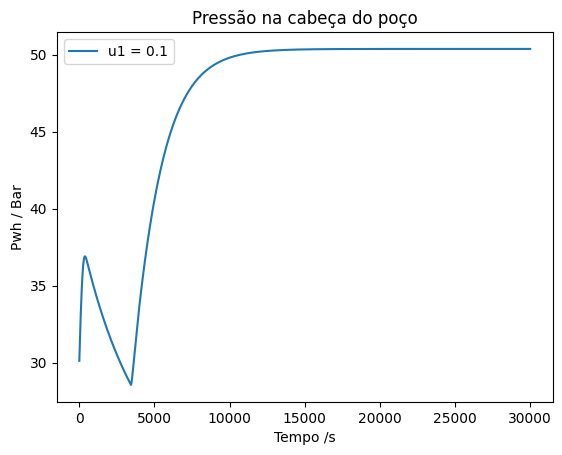

In [4]:
import numpy as np
import pandas as pd
import sys
from ModeloClassificado import fun_integrador, simular, run_simulation, simular_2



integrador, modelo = fun_integrador(dt=1)

y0 = [1713.946, 424.3868, 4454.146]
z0_vals = [
    7183839.554, 2991744.663, 7138588.549, 12043588.55,
    1.90714269, 14.13695208, 33.43556308, 2.911066071,
    30.52449701, 0.141369521, 281.8106616, 80.37817471
]

w_inj = 0.2
u1 = 0.1
GOR = 0.01

params = [w_inj,u1, GOR ]

t = np.arange(0, 30000, 1)

results = simular_2(integrador, modelo, params, y0, z0_vals, t)
plt.plot(t, results['Pwh']/1e5,  label=f'u1 = {u1}')
plt.title('Pressão na cabeça do poço')
plt.xlabel('Tempo /s')
plt.ylabel('Pwh / Bar')
plt.legend()

u1_values = np.linspace(0.1, 1.0, 10)
w_inj_values = np.linspace(0.2, 2.0, 10)
GOR_values = [0.01]


plt.legend()

all_results = []
count = 0
total = len(GOR_values) * len(u1_values) * len(w_inj_values)
print(f"Iniciando {total} simulações...")


for gor_val in GOR_values:
    for u1 in u1_values:
        for w_inj in w_inj_values:
            count += 1
            try:
                integrador, modelo = fun_integrador(dt=1)
                resultado = run_simulation(integrador, modelo, w_inj, u1, gor_val, y0, z0_vals, t)
                all_results.append(resultado)
                print(f"Simulação {count}/{total} — Estado: {resultado['estado']}")
            except Exception as e:
                print(f"⚠️ Err33o na simulação {count}/{total}: {e}")


df = pd.DataFrame(all_results)

df.to_csv("resultados_estabilidade.csv", sep=';', decimal=',', index=False)



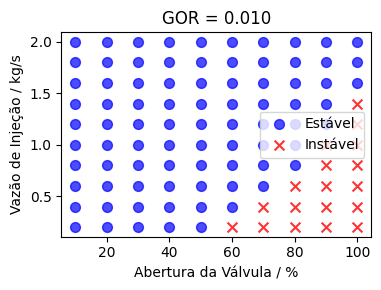

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("resultados_estabilidade.csv", sep=';', decimal=',')

GOR_value = 0.01
df_gor = df[df['GOR'] == GOR_value]

# Cria o gráfico
plt.figure(figsize=(4, 3))

df_estavel = df_gor[df_gor['estado'] == 0]
plt.scatter(df_estavel['u1'] * 100, df_estavel['w_inj'], color='blue', s=50, alpha=0.7, label='Estável', marker='o')

# Pontos instáveis (X vermelhos)
df_instavel = df_gor[df_gor['estado'] == 1]
plt.scatter(df_instavel['u1'] * 100, df_instavel['w_inj'], color='red', s=50, alpha=0.8, label='Instável', marker='x')


plt.xlabel('Abertura da Válvula / %')
plt.ylabel('Vazão de Injeção / kg/s')
plt.title(f'GOR = {GOR_value:.3f}')
plt.legend()
plt.grid(False)
plt.xticks([20, 40, 60, 80, 100])
plt.tight_layout()
plt.show()




In [ ]:



w_inj = 1.2  # Vazão de injeção
GOR = 0.01       # Relação gás-óleo
u1 = 1   # Abertura da válvula choke
t0 = 0
tf = 50000
dt = 1.0
t = np.arange(t0, tf, dt)
t_horas = t / 3600

# --- Condições iniciais e palpites ---
initial_conditions = [
    [1100, 300, 1300],
    [1500, 200, 1000],
    [880, 200, 1000],
    [880, 800, 2000],
    [1300, 500, 1500],
    [1000, 800, 1100],
    [2000, 600, 1800],
    [1479.7832, 329.0115, 4236.6052]
]

guess = [
    [1703.4457139699723, 292.86358361433764, 5882.761221681055],
    [2160.958500573357, 250.705897932019, 7852.996350383134]
]

x_guess = guess[1]


sol = root(
    fun_fsolve,
    x_guess,
    args=(w_inj, u1, GOR),
    method='broynde2', tol = 1e-3
)  # Levenberg-Marquardt



if sol.success:
    equilibrium_point = sol.x
    print("✅ Ponto de equilíbrio encontrado com sucesso!")
    print(f"   x1_eq = {equilibrium_point[0]:.4f} kg (Gás Anular)")
    print(f"   x2_eq = {equilibrium_point[1]:.4f} kg (Gás Tubulação)")
    print(f"   x3_eq = {equilibrium_point[2]:.4f} kg (Óleo Tubulação)")

    # Verificação: resíduos das EDOs no ponto
    derivatives_at_eq = fun_fsolve(equilibrium_point, w_inj, u1, GOR)
    print("\n   Resíduos (dx/dt) no ponto de equilíbrio:")
    print(f"   dx1/dt = {derivatives_at_eq[0]:.2e}")
    print(f"   dx2/dt = {derivatives_at_eq[1]:.2e}")
    print(f"   dx3/dt = {derivatives_at_eq[2]:.2e}")
else:
    print("❌ scipy.optimize.root NÃO convergiu.")
    print(f"Mensagem: {sol.message}")
    equilibrium_point = None





In [29]:
import numpy as np
import pandas as pd
import casadi as ca
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys


from ModeloClassificado import fun_integrador, simular_2, modelo 


w_inj = 1.0
u1 = 1.0
GOR = 0.01
params = [w_inj, u1, GOR]
print(f"Analisando ponto: w_inj={w_inj}, u1={u1}, GOR={GOR}")

equilibrium_point = None

df_equilibrio = pd.read_csv("mapa_equilibrio_casadi.csv", sep=';', decimal=',')

    
   
 
ponto_op = df_equilibrio[
        (np.isclose(df_equilibrio['w_inj'], w_inj)) &
        (np.isclose(df_equilibrio['u1'], u1)) &
        (np.isclose(df_equilibrio['GOR'], GOR))
    ]

if ponto_op.empty:
    print(f"Ponto de equilíbrio para (w_inj={w_inj}, u1={u1}) não encontrado no CSV.")
else:
   
    eq_row = ponto_op.iloc[0]
    equilibrium_point = [eq_row['x1_eq'], eq_row['x2_eq'], eq_row['x3_eq']]
    print(f"Ponto de Equilíbrio (do CSV): {np.round(equilibrium_point, 2)}")
    
    if eq_row.get('status', 'convergiu') != 'convergiu':
            print(f"AVISO: Ponto do CSV não convergiu (Status: {eq_row['status']}). Pode ser instável.")



y0_list = [
    [2045.7, 169.0, 9588.1],
    [2500.0, 100.0, 10000.0],
    [1800.0, 200.0, 8000.0], 
    [1453.12,  336.56 ,4067.43]
]


z0_vals = [
    7183839.554, 2991744.663, 7138588.549, 12043588.55,
    1.90714269, 14.13695208, 33.43556308, 2.911066071,
    30.52449701, 0.141369521, 281.8106616, 80.37817471
]


t0, tf, dt = 0, 20000, 1
t = np.arange(t0, tf, dt)


all_trajectories = []
integrador, modelo_func = fun_integrador(dt=dt)

for y0_i in y0_list:
    print(f"  Simulando de y0 = {np.round(y0_i, 1)}...")
    results = simular_2(integrador, modelo_func, params, y0_i, z0_vals, t)
    all_trajectories.append(results)



Analisando ponto: w_inj=1.0, u1=1.0, GOR=0.01
Ponto de Equilíbrio (do CSV): [1510.12  321.03 4424.3 ]
  Simulando de y0 = [2045.7  169.  9588.1]...
  Simulando de y0 = [ 2500.   100. 10000.]...
  Simulando de y0 = [1800.  200. 8000.]...
  Simulando de y0 = [1453.1  336.6 4067.4]...


In [30]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# --- Criar figura interativa ---
fig = go.Figure()

# Adicionar cada trajetória
for i, traj in enumerate(all_trajectories):
    fig.add_trace(go.Scatter3d(
        x=traj['x1'], y=traj['x2'], z=traj['x3'],
        mode='lines',
        line=dict(width=4),
        name=f"Trajetória {i+1}"
    ))

# Ponto inicial (preto)
for traj in all_trajectories:
    fig.add_trace(go.Scatter3d(
        x=[traj['x1'][0]], y=[traj['x2'][0]], z=[traj['x3'][0]],
        mode='markers',
        marker=dict(size=6, color='black', symbol='circle'),
        name='Início'
    ))



# Ponto de equilíbrio (vermelho)
if equilibrium_point is not None:
    fig.add_trace(go.Scatter3d(
        x=[equilibrium_point[0]], y=[equilibrium_point[1]], z=[equilibrium_point[2]],
        mode='markers',
        marker=dict(size=4, color='red', symbol='x'),
        name='Ponto de Equilíbrio'
    ))

# Layout
fig.update_layout(
    scene=dict(
        xaxis_title='x1 (Massa Gás Anular)',
        yaxis_title='x2 (Massa Gás Tubo)',
        zaxis_title='x3 (Massa Óleo Tubo)',
    ),
    title=f"Mapa de Trajetórias 3D Interativo (w_inj={w_inj}, u1={u1})",
    showlegend=True,
    template="plotly_white"
)

fig.show()
